In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_amb.mat to dataset_amb.mat
Saving dataset_elec.mat to dataset_elec.mat


In [2]:
import scipy.io
import pandas as pd
import numpy as np

elec_data = scipy.io.loadmat('dataset_elec.mat')
amb_data = scipy.io.loadmat('dataset_amb.mat')


print("Elec keys:", elec_data.keys())
print("Amb keys:", amb_data.keys())

_
elec_keys = [k for k in elec_data.keys() if not k.startswith('__')]
amb_keys = [k for k in amb_data.keys() if not k.startswith('__')]

print("Filtered Elec keys:", elec_keys)
print("Filtered Amb keys:", amb_keys)

for k in elec_keys:
    print(f"Shape of {k}: {elec_data[k].shape}")
for k in amb_keys:
    print(f"Shape of {k}: {amb_data[k].shape}")

Elec keys: dict_keys(['__header__', '__version__', '__globals__', 'idc1', 'idc2', 'vdc1', 'vdc2'])
Amb keys: dict_keys(['__header__', '__version__', '__globals__', 'f_nv', 'irr', 'pvt'])
Filtered Elec keys: ['idc1', 'idc2', 'vdc1', 'vdc2']
Filtered Amb keys: ['f_nv', 'irr', 'pvt']
Shape of idc1: (1, 1373798)
Shape of idc2: (1, 1373798)
Shape of vdc1: (1, 1373798)
Shape of vdc2: (1, 1373798)
Shape of f_nv: (1373798, 1)
Shape of irr: (1, 1373798)
Shape of pvt: (1, 1373798)


In [3]:
import pandas as pd
import numpy as np
import scipy.io


data_dict = {
    'idc1': elec_data['idc1'].flatten(),
    'idc2': elec_data['idc2'].flatten(),
    'vdc1': elec_data['vdc1'].flatten(),
    'vdc2': elec_data['vdc2'].flatten(),
    'f_nv': amb_data['f_nv'].flatten(),
    'irr': amb_data['irr'].flatten(),
    'pvt': amb_data['pvt'].flatten()
}

df = pd.DataFrame(data_dict)

# Calculate string power
df['p1'] = df['vdc1'] * df['idc1']
df['p2'] = df['vdc2'] * df['idc2']
df['p_total'] = df['p1'] + df['p2']

# Check unique fault labels
print("Unique f_nv labels:", df['f_nv'].unique())

# Sample the data to understand the healthy baseline
healthy = df[df['f_nv'] == 0]
print("Healthy stats:\n", healthy[['p1', 'p2', 'p_total', 'irr', 'pvt']].describe())

# Inspect mean power per label.
summary = df.groupby('f_nv')[['p1', 'p2', 'p_total']].mean()
print("Mean power per fault label:\n", summary)

Unique f_nv labels: [0 4 3 2 1]
Healthy stats:
                  p1            p2       p_total           irr           pvt
count  1.162931e+06  1.162931e+06  1.162931e+06  1.162931e+06  1.162931e+06
mean   4.882497e+02  4.739518e+02  9.622015e+02  2.048314e+02  2.081519e+01
std    8.471635e+02  8.326656e+02  1.679670e+03  3.470097e+02  1.383588e+01
min    1.887270e-02  1.621440e-03  2.152130e-02 -3.810000e-02 -1.654300e+00
25%    6.677132e-02  1.668403e-02  8.115622e-02  1.263300e+00  1.138010e+01
50%    1.429639e-01  5.211800e-02  1.865601e-01  1.441900e+00  1.699610e+01
75%    3.148892e+02  2.958514e+02  6.114771e+02  2.602400e+02  2.756805e+01
max    2.476888e+03  2.473801e+03  4.944523e+03  1.085920e+03  6.082150e+01
Mean power per fault label:
                p1           p2      p_total
f_nv                                       
0      488.249669   473.951841   962.201510
1     2307.622307  1720.624431  4028.246738
2     2273.096261  1970.764766  4243.861027
3     1387.651683  

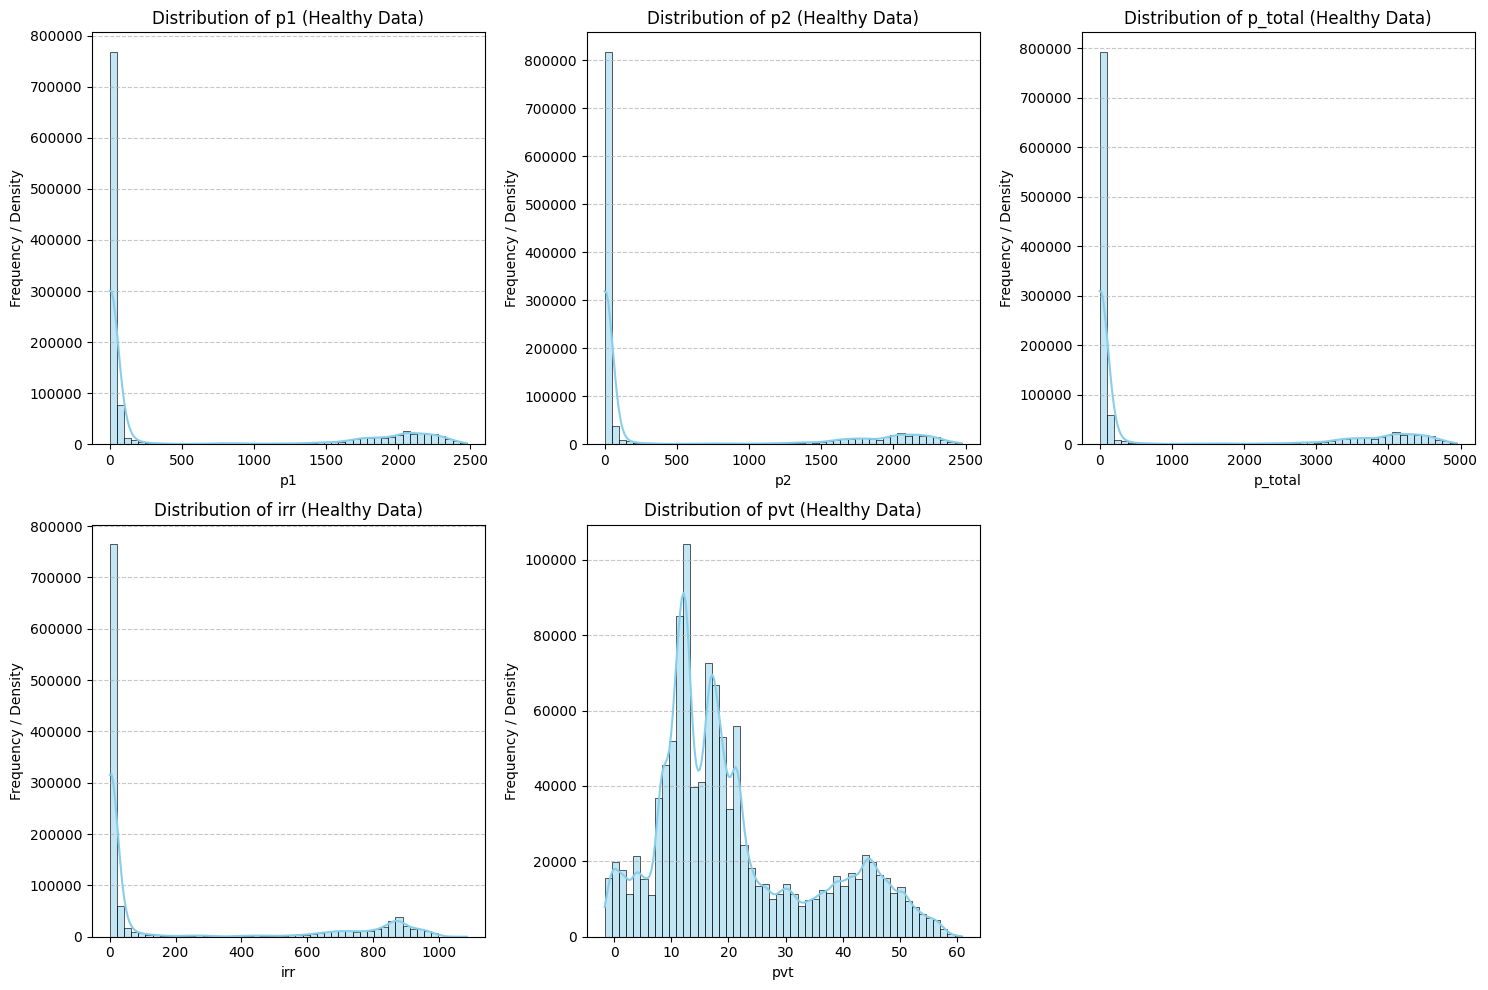

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = ['p1', 'p2', 'p_total', 'irr', 'pvt']

#subplots for each variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_plot):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns, position i+1
    sns.histplot(healthy[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {col} (Healthy Data)')
    plt.xlabel(col)
    plt.ylabel('Frequency / Density')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

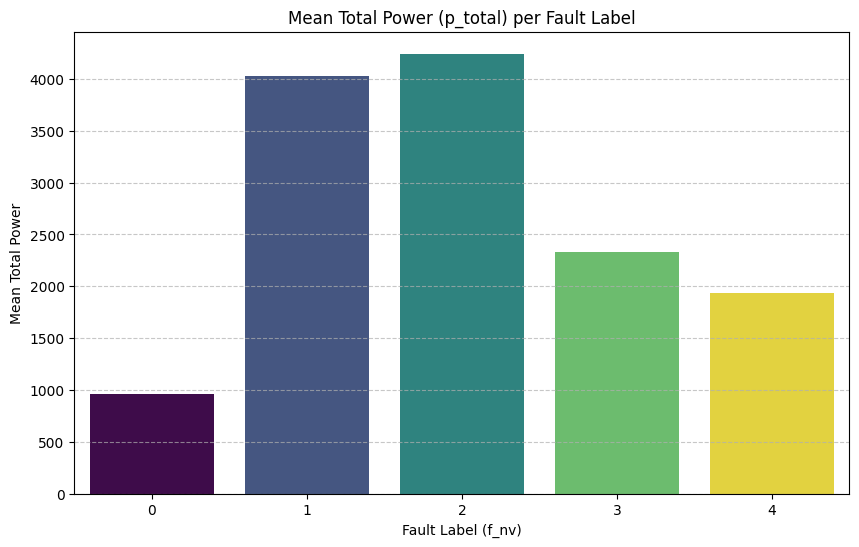

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


summary_reset = summary.reset_index()

# Plot 1: Total Power per Fault Label
plt.figure(figsize=(10, 6))
sns.barplot(x='f_nv', y='p_total', data=summary_reset, hue='f_nv', palette='viridis', legend=False)
plt.title('Mean Total Power (p_total) per Fault Label')
plt.xlabel('Fault Label (f_nv)')
plt.ylabel('Mean Total Power')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

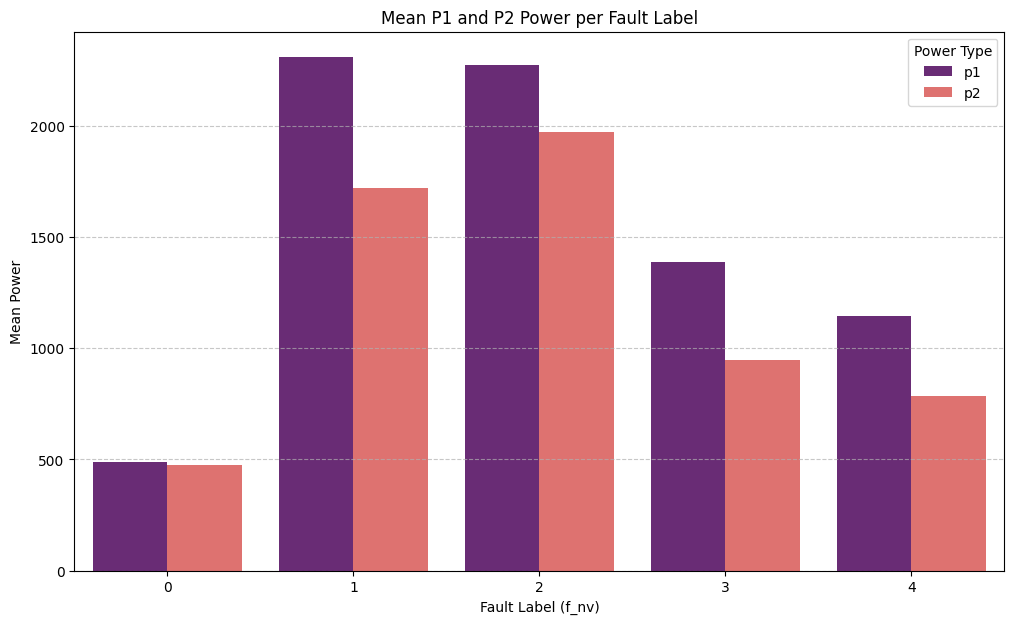

In [5]:
# Plot 2: P1 and P2 Power per Fault Label
plt.figure(figsize=(12, 7))

df_melted = summary_reset.melt(id_vars=['f_nv'], value_vars=['p1', 'p2'], var_name='Power Type', value_name='Mean Power')
sns.barplot(x='f_nv', y='Mean Power', hue='Power Type', data=df_melted, palette='magma')

plt.title('Mean P1 and P2 Power per Fault Label')
plt.xlabel('Fault Label (f_nv)')
plt.ylabel('Mean Power')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Power Type')
plt.show()

In [8]:
# Check average irradiance per label
irr_summary = df.groupby('f_nv')[['irr', 'p_total']].mean()
print("Average Irradiance and Power per Label:\n", irr_summary)

# Let's map f_nv to "Strings Affected" (1 or 2)
# We exclude f_nv == 0 as it's the healthy reference.
# Usually:
# 1 -> String 1 fault (1 string)
# 2 -> String 2 fault (1 string)
# 3 -> Both strings (2 strings)
# 4 -> Both strings (2 strings)
# Verify by checking p1 and p2 compared to expected.

# For healthy (0), calculate the relationship: Power = m * Irr
healthy_df = df[df['f_nv'] == 0]
m, c = np.polyfit(healthy_df['irr'], healthy_df['p_total'], 1)
print(f"P_expected model: P = {m:.4f} * irr + {c:.4f}")

# Calculate Power Loss for all rows
df['p_expected'] = m * df['irr'] + c
df['p_loss_raw'] = df['p_expected'] - df['p_total']
# Normalize Power Loss (Va) to [0, 1]
df['p_loss_norm'] = df['p_loss_raw'] / df['p_expected']
df['Va'] = df['p_loss_norm'].clip(0, 1)

# Map Vb (Strings Affected)
def map_strings(label):
    if label in [1, 2]: return 1
    if label in [3, 4]: return 2
    return 0

df['Vb_raw'] = df['f_nv'].apply(map_strings)
# Normalize Vb to [0, 1] for the formula (1 -> 0, 2 -> 1)
fault_df = df[df['f_nv'] != 0].copy()
fault_df['Vb_norm'] = fault_df['Vb_raw'] - 1 # 1 becomes 0, 2 becomes 1

# Check correlation with Fault Label (f_nv)
corr_a = fault_df['Va'].corr(fault_df['f_nv'])
corr_b = fault_df['Vb_norm'].corr(fault_df['f_nv'])

print(f"Correlation of Power Loss (Va) with Fault Label: {corr_a:.4f}")
print(f"Correlation of Strings Affected (Vb) with Fault Label: {corr_b:.4f}")

# Sensitivity check
from sklearn.ensemble import RandomForestClassifier
X = fault_df[['Va', 'Vb_norm']]
y = fault_df['f_nv']
model = RandomForestClassifier(n_estimators=10).fit(X, y)
importances = model.feature_importances_
print(f"Feature Importances - Power Loss: {importances[0]:.4f}, Strings Affected: {importances[1]:.4f}")

Average Irradiance and Power per Label:
              irr      p_total
f_nv                         
0     204.831369   962.201510
1     929.460652  4028.246738
2     932.327808  4243.861027
3     941.909287  2333.479927
4     502.893033  1932.023426
P_expected model: P = 4.8232 * irr + -25.7442
Correlation of Power Loss (Va) with Fault Label: 0.1252
Correlation of Strings Affected (Vb) with Fault Label: 0.9462
Feature Importances - Power Loss: 0.4808, Strings Affected: 0.5192


In [9]:
import statsmodels.api as sm

# Linear Regression to see standardized coefficients
# target is f_nv (relative to fault cases)
X = fault_df[['Va', 'Vb_norm']]
X = sm.add_constant(X)
y = fault_df['f_nv']

results = sm.OLS(y, X).fit()
print(results.summary())

# Normalized influence (comparing coefficients)
coeffs = results.params
print("\nRegression Coefficients:")
print(f"Power Loss (Va): {coeffs['Va']:.4f}")
print(f"Strings Affected (Vb_norm): {coeffs['Vb_norm']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   f_nv   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 9.342e+05
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:56:48   Log-Likelihood:                 29541.
No. Observations:              210867   AIC:                        -5.908e+04
Df Residuals:                  210864   BIC:                        -5.905e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6455      0.002    997.140      0.0

| Variable                   |  Coefficient (Influence Strength) | Relative Impact|
|----------------------------|-----------------------------------|----------------|
| Number of Strings Affected | 2.36                              | High (Dominant)|
| Power Loss                 | 0.17                              | Low (Secondary)|

To measure the combined effect of two variables, we use a weighted scoring formula.
Since the variables are on different scales (0–1 and 1–2), they must first be normalized
to the same 0–1 range.

1. Normalization

   Variable A (Va): Already between 0 and 1, therefore no change is needed.

   Variable B (Vb):  Currently 1 or 2, lets convert it to 0 or 1 using:
                       Vb_norm = Vb - 1

2. Weighted Score Formula

   Assign weights wa and wb such that:

      wa + wb = 1

     Final Score  = (Va * wa) + (Vb_norm * wb)